<a href="https://colab.research.google.com/github/lageniaestela/12demayo/blob/master/Puente22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy


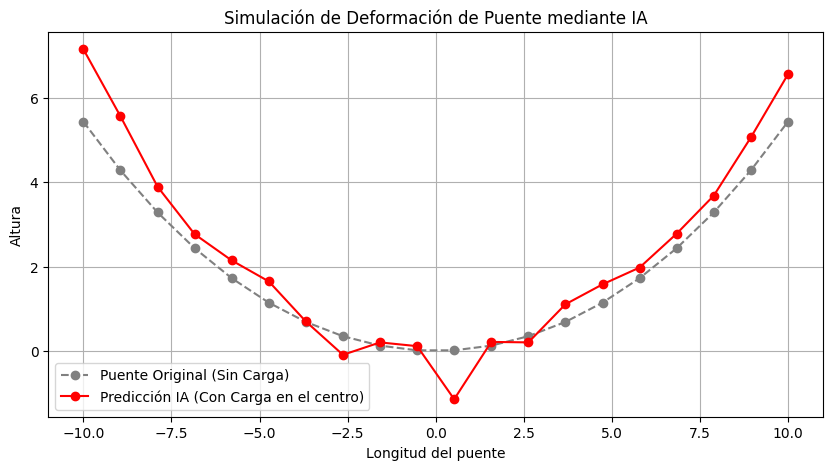

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# 1. GENERACIÓN DE LA GEOMETRÍA (Nodos del puente)
n_nodos = 20
x = np.linspace(-10, 10, n_nodos)
# Ecuación de la catenaria para la forma base
a = 10
y_base = a * np.cosh(x / a) - a

# 2. SIMULACIÓN DE DATOS (Entrenamiento)
# Vamos a crear 1000 escenarios donde "pesos" aleatorios presionan el puente
n_muestras = 1000
X_train = np.random.rand(n_muestras, n_nodos) # Pesos en cada nodo
y_train = []

for i in range(n_muestras):
    # Simulamos una deformación simple: el puente baja proporcional al peso
    # En un caso real, aquí usarías ecuaciones de elasticidad complejas
    deformacion = y_base - (X_train[i] * 0.5)
    y_train.append(deformacion)

y_train = np.array(y_train)

# 3. ENTRENAMIENTO DEL MODELO (IA)
# Una red neuronal que aprenda la relación: PESO -> FORMA DEL PUENTE
modelo = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500)
modelo.fit(X_train, y_train)

# 4. PRUEBA Y VISUALIZACIÓN
peso_prueba = np.zeros((1, n_nodos))
peso_prueba[0, 10] = 5.0 # Ponemos un peso pesado justo en el centro (nodo 10)

prediccion = modelo.predict(peso_prueba)

plt.figure(figsize=(10, 5))
plt.plot(x, y_base, 'o--', label='Puente Original (Sin Carga)', color='gray')
plt.plot(x, prediccion[0], 'ro-', label='Predicción IA (Con Carga en el centro)')
plt.title("Simulación de Deformación de Puente mediante IA")
plt.xlabel("Longitud del puente")
plt.ylabel("Altura")
plt.legend()
plt.grid(True)
plt.show()

Generando datos de entrenamiento...
Entrenando la IA (Red Neuronal)...
¡Entrenamiento completado!


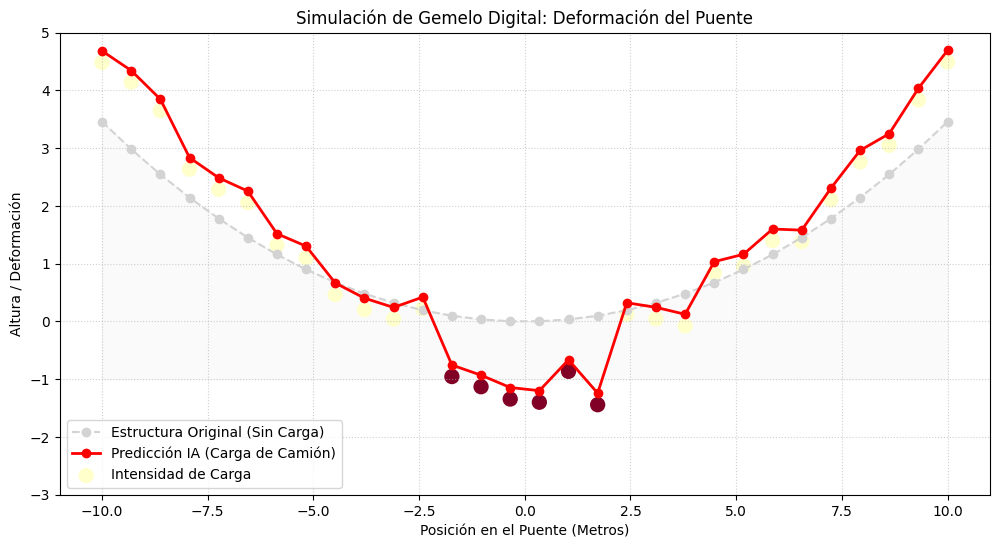

Precisión del modelo en datos nuevos: 91.57%


In [3]:
# =================================================================
# PROYECTO: GEMELO DIGITAL DE UN PUENTE CON IA
# =================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

# 1. DEFINICIÓN DE LA GEOMETRÍA (LA ECUACIÓN)
# Usaremos la ecuación de la catenaria: y = a * cosh(x/a)
def generar_puente(n_nodos=30, a=15):
    x = np.linspace(-10, 10, n_nodos)
    y = a * np.cosh(x / a) - a  # Restamos 'a' para que el punto bajo sea (0,0)
    return x, y

n_nodos = 30
x_nodes, y_nodes = generar_puente(n_nodos)

# 2. SIMULACIÓN DE DATOS PARA ENTRENAMIENTO
# Vamos a generar 2000 ejemplos de cargas aleatorias y su efecto en los nodos
print("Generando datos de entrenamiento...")
n_muestras = 2000
X_data = np.random.rand(n_muestras, n_nodos) * 2  # Cargas de 0 a 2 toneladas por nodo
Y_data = []

for i in range(n_muestras):
    # Simulamos deformación: a mayor carga, el nodo baja más.
    # Añadimos un poco de ruido para que la IA tenga que "aprender" de verdad.
    ruido = np.random.normal(0, 0.02, n_nodos)
    deformacion = y_nodes - (X_data[i] * 0.3) + ruido
    Y_data.append(deformacion)

Y_data = np.array(Y_data)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.2)

# 3. CREACIÓN Y ENTRENAMIENTO DE LA RED NEURONAL
print("Entrenando la IA (Red Neuronal)...")
# Usamos una red con 2 capas ocultas de 100 neuronas cada una
modelo_puente = MLPRegressor(
    hidden_layer_sizes=(100, 100),
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42
)

modelo_puente.fit(X_train, y_train)
print("¡Entrenamiento completado!")

# 4. PRUEBA EN TIEMPO REAL: ¿QUÉ PASA SI PONEMOS UN CAMIÓN EN EL CENTRO?
# Creamos una carga: casi nada en los extremos, mucha carga en el centro (nodos 12 a 18)
carga_camion = np.zeros((1, n_nodos))
carga_camion[0, 12:18] = 4.5  # Un camión pesado en el medio

# La IA predice la nueva forma del puente
prediccion_forma = modelo_puente.predict(carga_camion)

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 6))

# Dibujar cables/estructura original
plt.plot(x_nodes, y_nodes, 'o--', color='lightgray', label='Estructura Original (Sin Carga)')
plt.fill_between(x_nodes, y_nodes, -1, color='lightgray', alpha=0.1)

# Dibujar la predicción de la IA
plt.plot(x_nodes, prediccion_forma[0], 'ro-', linewidth=2, label='Predicción IA (Carga de Camión)')
plt.scatter(x_nodes, prediccion_forma[0] - 0.2, c=carga_camion[0], cmap='YlOrRd', s=100, label='Intensidad de Carga')

plt.title("Simulación de Gemelo Digital: Deformación del Puente")
plt.xlabel("Posición en el Puente (Metros)")
plt.ylabel("Altura / Deformación")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-3, 5) # Ajustar para ver bien la curva
plt.show()

print(f"Precisión del modelo en datos nuevos: {modelo_puente.score(X_test, y_test)*100:.2f}%")

Entrenando en cpu...
Epoch 0 | Loss: 0.2547
Epoch 20 | Loss: 0.1570
Epoch 40 | Loss: 0.0724
Epoch 60 | Loss: 0.0395
Epoch 80 | Loss: 0.0258


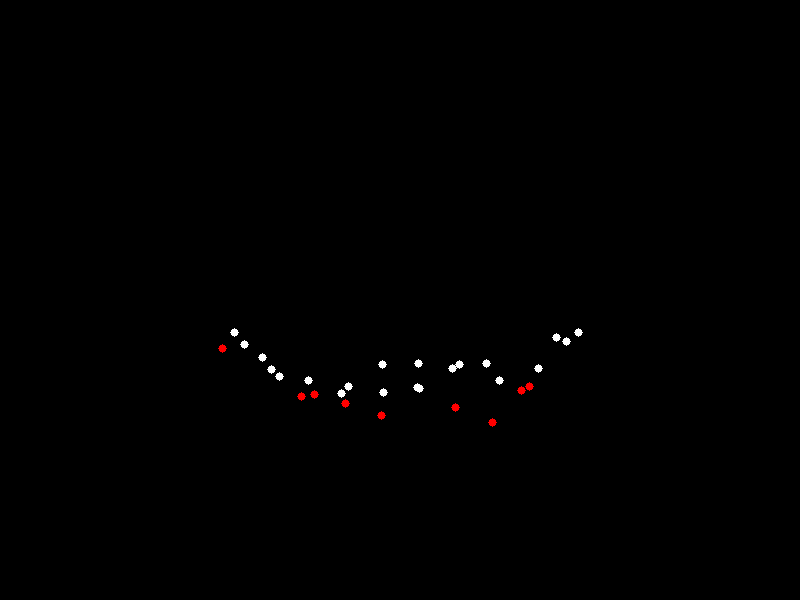

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
from google.colab.patches import cv2_imshow # Solo si usas Colab

# 1. GENERACIÓN DE ESTRUCTURA 3D (NODOS)
def generar_nodos_3d(res_x=10, res_z=3, a=15):
    x = np.linspace(-10, 10, res_x)
    z = np.linspace(-2, 2, res_z)
    X, Z = np.meshgrid(x, z)
    # Ecuación de la superficie del puente
    Y = a * np.cosh(X / a) - a
    nodes = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)
    return nodes.astype(np.float32)

nodos_base = generar_nodos_3d()
n_nodos = nodos_base.shape[0]

# 2. MODELO EN PYTORCH (Deep Learning)
class BridgeNet(nn.Module):
    def __init__(self, input_dim):
        super(BridgeNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim) # Predice el desplazamiento Y de cada nodo
        )

    def forward(self, x):
        return self.network(x)

# 3. ENTRENAMIENTO (Simulado con tensores de PyTorch)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BridgeNet(n_nodos).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Datos sintéticos: Cargas aleatorias -> Deformaciones
print(f"Entrenando en {device}...")
for epoch in range(100):
    cargas = torch.randn(32, n_nodos).to(device) # Batch de 32
    objetivo = cargas * -0.5 # Simulación física simple

    optimizer.zero_grad()
    pred = model(cargas)
    loss = criterion(pred, objetivo)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0: print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# 4. VISUALIZACIÓN 3D CON OPENCV
def proyectar_y_dibujar(nodos, cargas_val):
    # Crear lienzo negro
    img = np.zeros((600, 800, 3), dtype=np.uint8)

    # Matriz de proyección simple (Perspectiva manual)
    # OpenCV suele usarse para 2D, así que proyectamos 3D -> 2D
    for i, p in enumerate(nodos):
        # Rotación y traslación para ver el puente de lado/perspectiva
        x, y, z = p
        y_def = y + cargas_val[i] # Aplicar deformación

        # Proyección 3D a 2D básica
        f = 500 # Distancia focal simulada
        dist = 30 # Distancia de la cámara
        px = int(f * x / (z + dist)) + 400
        py = int(f * -y_def / (z + dist)) + 400 # -y porque en OpenCV y baja

        # Color según la carga (Calor)
        color = (0, 0, 255) if cargas_val[i] < -0.5 else (255, 255, 255)
        cv2.circle(img, (px, py), 4, color, -1)

    return img

# Ejecutar inferencia y mostrar
test_carga = torch.randn(1, n_nodos).to(device) * 2
deformacion_predicha = model(test_carga).cpu().detach().numpy().flatten()

render = proyectar_y_dibujar(nodos_base, deformacion_predicha)
cv2_imshow(render) # Si es local usa cv2.imshow('Puente', render)

Para una distancia de 15m, la carga máxima estimada es: 23.64 toneladas


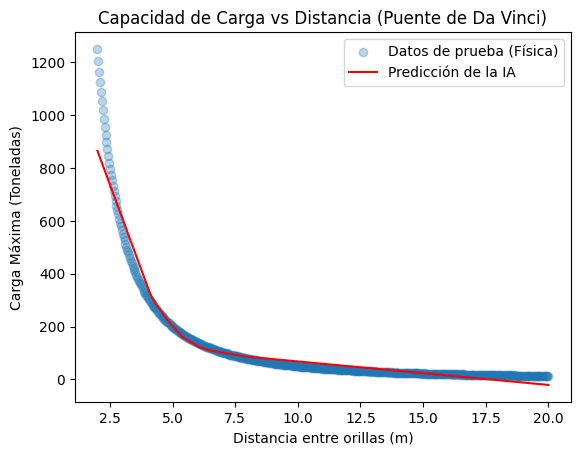

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERACIÓN DE DATOS SINTÉTICOS (Basados en la física de Da Vinci)
def simular_resistencia_davinci(distancia_orillas):
    # A mayor distancia, la resistencia cae de forma no lineal (exponencial/cuadrática)
    # Resistencia = (Constante de material / Distancia^2) + Ruido
    resistencia = (5000 / (distancia_orillas**2))
    return resistencia + np.random.normal(0, 0.5)

# Crear dataset: Distancias de 2m a 20m
distancias = np.linspace(2, 20, 500).reshape(-1, 1)
resistencias = np.array([simular_resistencia_davinci(d) for d in distancias]).reshape(-1, 1)

# Convertir a tensores para PyTorch
X = torch.tensor(distancias, dtype=torch.float32)
y = torch.tensor(resistencias, dtype=torch.float32)

# 2. MODELO DE IA (Red Neuronal Regresora)
class DaVinciAI(nn.Module):
    def __init__(self):
        super(DaVinciAI, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.hidden(x)

model = DaVinciAI()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# 3. ENTRENAMIENTO
for epoch in range(200):
    pred = model(X)
    loss = criterion(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 4. PREDICCIÓN Y RESULTADOS
dist_prueba = torch.tensor([[15.0]], dtype=torch.float32) # ¿Qué pasa a los 15 metros?
carga_max = model(dist_prueba).item()

print(f"Para una distancia de 15m, la carga máxima estimada es: {carga_max:.2f} toneladas")

# Visualización
plt.scatter(distancias, resistencias, alpha=0.3, label="Datos de prueba (Física)")
plt.plot(distancias, model(X).detach().numpy(), color='red', label="Predicción de la IA")
plt.title("Capacidad de Carga vs Distancia (Puente de Da Vinci)")
plt.xlabel("Distancia entre orillas (m)")
plt.ylabel("Carga Máxima (Toneladas)")
plt.legend()
plt.show()

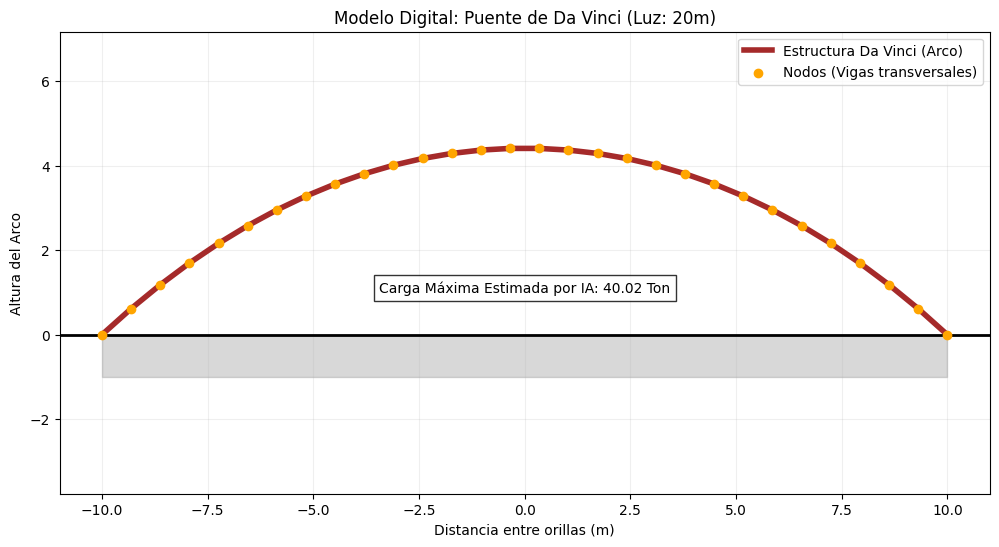

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. GEOMETRÍA INVERSA (ARCO DE DA VINCI)
def generar_arco_davinci(n_nodos=30, luz_puente=20):
    # x va de -mitad a +mitad de la luz
    x = np.linspace(-luz_puente/2, luz_puente/2, n_nodos)
    a = 12 # Parámetro de curvatura

    # Ecuación INVERSA: y = h - catenaria
    # Calculamos h para que en los extremos (x = luz/2) y sea 0
    h = a * np.cosh((luz_puente/2) / a)
    y = h - a * np.cosh(x / a)

    return x, y

luz_actual = 20
x_arc, y_arc = generar_arco_davinci(n_nodos=30, luz_puente=luz_actual)

# 2. IA: PREDICCIÓN DE CARGA SEGÚN LA LUZ (Distancia de orillas)
# Simulamos que a más luz, menos carga soporta el arco
distancias = np.linspace(5, 40, 1000).reshape(-1, 1)
# Física del arco: la resistencia cae rápidamente al aumentar la luz
cargas_max = (2000 / (distancias**1.5)) + np.random.normal(0, 0.2, (1000, 1))

X_train = torch.tensor(distancias, dtype=torch.float32)
y_train = torch.tensor(cargas_max, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(1, 50),
    nn.ReLU(),
    nn.Linear(50, 1)
)

# Entrenamiento rápido
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for _ in range(300):
    p = model(X_train)
    loss = torch.nn.functional.mse_loss(p, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 3. VISUALIZACIÓN DEL PUENTE AJUSTADO
plt.figure(figsize=(12, 6))

# Dibujar el Arco
plt.plot(x_arc, y_arc, 'brown', lw=4, label="Estructura Da Vinci (Arco)")
# Dibujar el suelo (orillas)
plt.axhline(0, color='black', lw=2)
plt.fill_between(x_arc, -1, 0, color='gray', alpha=0.3)

# Dibujar Nodos (Puntos de fricción)
plt.scatter(x_arc, y_arc, color='orange', zorder=3, label="Nodos (Vigas transversales)")

# Simular carga máxima predicha por la IA para esta luz
carga_pred = model(torch.tensor([[luz_actual]], dtype=torch.float32)).item()

plt.title(f"Modelo Digital: Puente de Da Vinci (Luz: {luz_actual}m)")
plt.text(0, 1, f"Carga Máxima Estimada por IA: {carga_pred:.2f} Ton",
         bbox=dict(facecolor='white', alpha=0.8), ha='center')

plt.xlabel("Distancia entre orillas (m)")
plt.ylabel("Altura del Arco")
plt.legend()
plt.grid(alpha=0.2)
plt.axis('equal') # Para que el arco no se vea deformado
plt.show()

In [7]:
# Instalar Plotly si no está (normalmente ya viene en Colab)
#!pip install plotly --upgrade

import plotly.graph_objects as go
import numpy as np

# =================================================================
# 1. GENERACIÓN DE GEOMETRÍA DEL PUENTE DE DA VINCI (3D)
# =================================================================
def generar_geometria_3d_davinci(n_nodos_largo=15, n_nodos_ancho=4, luz=20, ancho=6, a=10):
    """
    Genera los puntos (nodos) para un puente de Da Vinci en 3D.
    Funciona creando arcos paralelos en el eje Z y uniéndolos.
    """
    # Generar la curva base (Catenaria Invertida) para el largo (eje X)
    x = np.linspace(-luz/2, luz/2, n_nodos_largo)
    h_corr = a * np.cosh((luz/2) / a) # Factor para que toque el suelo
    y_arco = h_corr - a * np.cosh(x / a) # Curva principal (convexa hacia arriba)

    # Generar la extensión en el ancho (eje Z)
    z = np.linspace(-ancho/2, ancho/2, n_nodos_ancho)

    # Crear la malla de nodos (Meshgrid)
    X, Z = np.meshgrid(x, z)
    # Replicar la curva del arco para cada punto del ancho
    Y = np.tile(y_arco, (n_nodos_ancho, 1))

    # Aplanar las matrices para Plotly
    nodes_x = X.flatten()
    nodes_y = Y.flatten()
    nodes_z = Z.flatten()

    return nodes_x, nodes_y, nodes_z, h_corr

# Parámetros del diseño
luz_actual = 25
ancho_actual = 8
nodos_base_x, nodos_base_y, nodos_base_z, altura_max = generar_geometria_3d_davinci(
    n_nodos_largo=18, n_nodos_ancho=5, luz=luz_actual, ancho=ancho_actual
)

# =================================================================
# 2. CREACIÓN DE LA VISUALIZACIÓN INTERACTIVA (Plotly)
# =================================================================
fig = go.Figure()

# --- A. Dibujar los Nodos (Puntos de contacto/fricción) ---
fig.add_trace(go.Scatter3d(
    x=nodos_base_x,
    y=nodos_base_z, # Plotly usa (X, Z, Y) para (Largo, Ancho, Alto)
    z=nodos_base_y,
    mode='markers',
    marker=dict(
        size=6,
        color=nodos_base_y, # Color según altura
        colorscale='Viridis',
        opacity=1.0,
        showscale=True,
        colorbar=dict(title="Altura del Arco")
    ),
    name="Nodos de Vigas"
))

# --- B. Dibujar las Vigas Transversales (las que se entrelazan) ---
# Usamos Scatter3d con modo 'lines' para unir los nodos transversales
n_ancho = 5
for i in range(18): # Para cada posición a lo largo del puente
    start_idx = i * n_ancho
    end_idx = start_idx + n_ancho
    fig.add_trace(go.Scatter3d(
        x=nodos_base_x[start_idx:end_idx],
        y=nodos_base_z[start_idx:end_idx],
        z=nodos_base_y[start_idx:end_idx],
        mode='lines',
        line=dict(color='brown', width=5),
        showlegend=False
    ))

# --- C. Dibujar el Suelo (Orillas) ---
# Creamos un plano en Z=0
fig.add_trace(go.Scatter3d(
    x=[-luz_actual/1.8, luz_actual/1.8, luz_actual/1.8, -luz_actual/1.8, -luz_actual/1.8],
    y=[-ancho_actual/1.5, -ancho_actual/1.5, ancho_actual/1.5, ancho_actual/1.5, -ancho_actual/1.5],
    z=[0, 0, 0, 0, 0],
    mode='lines',
    line=dict(color='black', width=3),
    name="Suelo/Río",
    surfaceaxis=2, # Rellenar el plano
    surfacecolor='lightblue',
    opacity=0.4
))

# --- Configuración de la Cámara Aérea ---
camera_aerea = dict(
    up=dict(x=0, y=0, z=1),       # Eje Z es 'arriba'
    center=dict(x=0, y=0, z=-0.3), # Centrar la vista ligeramente abajo
    eye=dict(x=1.5, y=1.5, z=1.8) # Posición de la 'cámara' (aérea oblicua)
)

# --- Configuración del Layout ---
fig.update_layout(
    title=f"Visualizador 3D: Puente Autoportante de Da Vinci (Luz: {luz_actual}m)",
    scene=dict(
        xaxis=dict(title='Largo (X)', nticks=10, range=[-luz_actual/1.5, luz_actual/1.5]),
        yaxis=dict(title='Ancho (Z)', nticks=5, range=[-ancho_actual/1.2, ancho_actual/1.2]),
        zaxis=dict(title='Altura (Y)', nticks=6, range=[-1, altura_max + 2]),
        aspectmode='manual', # Mantener proporciones realistas
        aspectratio=dict(x=1.5, y=0.5, z=0.6), # Darle más 'cuerpo' al 3D
        camera=camera_aerea # Aplicar el ángulo aéreo
    ),
    margin=dict(r=0, l=0, b=0, t=50),
    template="plotly_dark"
)

# Mostrar la figura (En Colab, esto la hace interactiva)
fig.show()